In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats
import netCDF4  
import time
import utils as u

import sys
sys.path.insert(1, '/home/fainx/MyPythonLibrary/MAR-RECAP/libmar/')
import climbasis as climb
from climbasis import *
import domain as dom
import myplot
import numpy.ma as ma
from myplot import *
import obsinfo as obs
from obsinfo import *

In [3]:
folder_figure = '/bettik/PROJECTS/pr-regional-climate/fainx/figures/GRf/'
domain = 'MARFed'
domain_2 = 'GRf'

# Selection des données montagne vs plaine
alti_thrs = 3000

In [4]:
month_list = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
season_list = ["DJF","MAM","JJA","SON"]

### comparaison spin2 , different test de sensibilité => ne demande pas d'interpolations
### en complément de la carte initialement produite de comparaison de spin2 avec les différents forcage
### climatologie annuelle, avec les different test de sensibilité

In [232]:
# Removed pixels on domain boundaries
k =15

### MAR

In [233]:
# MAR topography
sourceDataGrid='/home/amoryc/'
fileName_grF='NST.2000.01.01.00.GRf.nc' #mettre a jour 
ds_grF= xr.open_dataset(sourceDataGrid+fileName_grF) # cette ligne a effacer, apres avoir remplacé ds_grF avec ds_SH
orog_mar = xr.open_dataset(sourceDataGrid+fileName_grF).SH.load()

orog_mar = orog_mar[k:-k,k:-k]
orog_mar = orog_mar.rename({'x': 'X', 'y':'Y'})

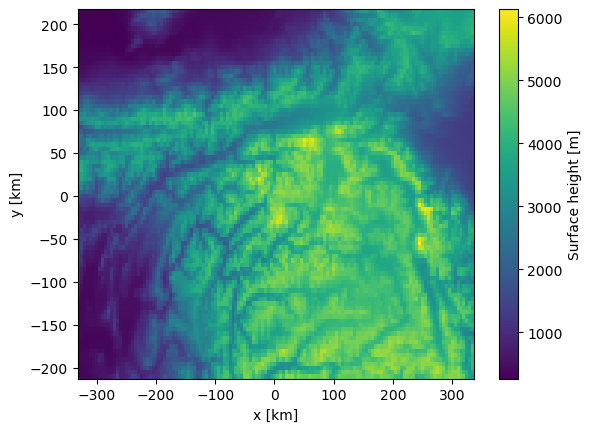

In [234]:
orog_mar.plot()

In [235]:
#MAR dataset
sourceData='/bettik/PROJECTS/pr-regional-climate/santolam/MARout/GRf/spin2/work/monthly/'
variable='TTZ' 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_GRf_2000-2023.nc'
dsF= xr.open_dataset(sourceData+fileNameF).isel(ZTQLEV=0).TTZ.load()

dsF = dsF.assign_coords(X=np.round(dsF.X.values))
dsF = dsF.assign_coords(Y=np.round(dsF.Y.values))
dsF = dsF.rename({'TIME': 'time'})

dsF = dsF.sel(time=slice("2000-01-01", "2020-12-31"))

model1='MAR'
res1=str('5kmx5km')

In [236]:
print('Fedchenko domain')
print('lon min',ds_grF.LON.values.min(),'lon max',ds_grF.LON.values.max())
print('lat min',ds_grF.LAT.values.min(),'lat max',ds_grF.LAT.values.max())

Fedchenko domain
lon min 67.45302 lon max 77.20667
lat min 36.148087 lat max 41.407486


In [237]:
# Enlever k pixels sur les contours
dsF = dsF[:,k:-k,k:-k]

lat_min=ds_grF.LAT.values.min()
lat_max=ds_grF.LAT.values.max()

lon_min=ds_grF.LON.values.min()
lon_max=ds_grF.LON.values.max()

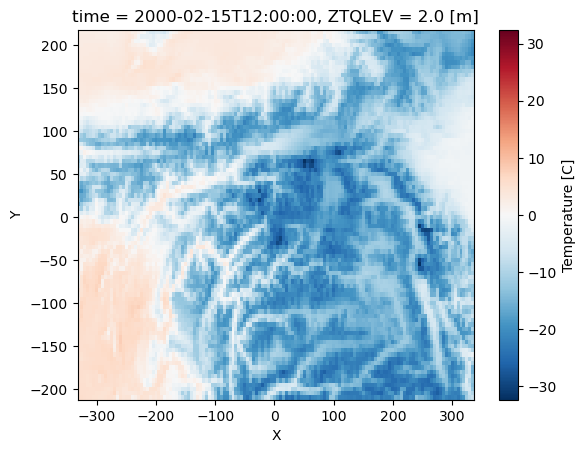

In [238]:
dsF.isel(time=1).plot()

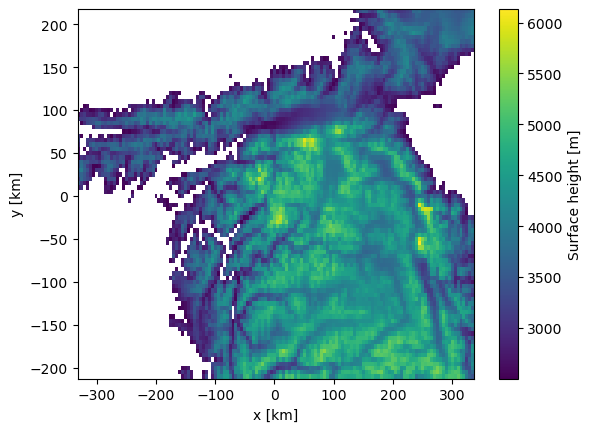

In [239]:
orog_mar.where(orog_mar > alti_thrs, drop=True).plot()
plt.savefig(folder_figure + 'MARorog/' +'MARorog_'+ domain_2+ '_above' + str(alti_thrs) +'m.png',format='png')

In [240]:
# Cette commande ne fonctionne pas : masked_dsF = dsF.where(orog_mar > 1000) ?????

#Autre approche avec numpy: 
dsF_data = dsF.values       
orog_data = orog_mar.values 

mask = orog_data > alti_thrs    
dsF_masked_data = np.where(mask, dsF_data, np.nan)

dsF_high = xr.DataArray(
    dsF_masked_data,
    coords=dsF.coords,
    dims=dsF.dims,
    name=dsF.name,
    attrs=dsF.attrs
)

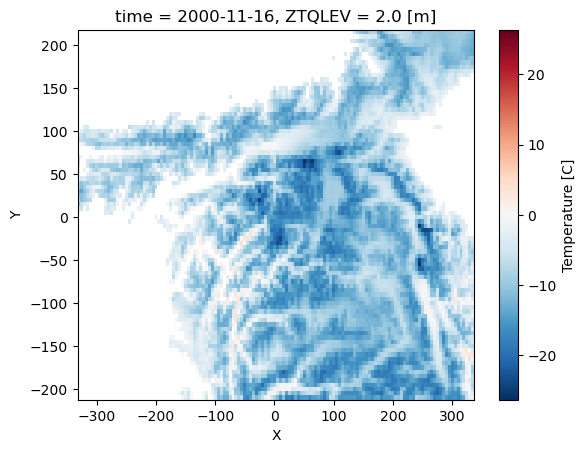

In [241]:
dsF_high.isel(time=10).plot(cmap='RdBu_r')

### ERA5

In [266]:
folder_era5='/bettik/PROJECTS/pr-regional-climate/fainx/era5/'

tmp_era5 = xr.open_mfdataset(folder_era5 + 'era5_GRf_t2m.nc').t2m.load()-273.15
tmp_era5=tmp_era5.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})
tmp_era5 = tmp_era5.sel(time=slice("2000-01-01", "2020-12-31"))
tmp_era5 = tmp_era5.where((tmp_era5.lat >= lat_min) & (tmp_era5.lat <= lat_max), drop=True)
tmp_era5 = tmp_era5.where((tmp_era5.lon >= lon_min) & (tmp_era5.lon <= lon_max), drop=True)

model2='ERA5'
res2=str('31kmx31km')

(25, 49)


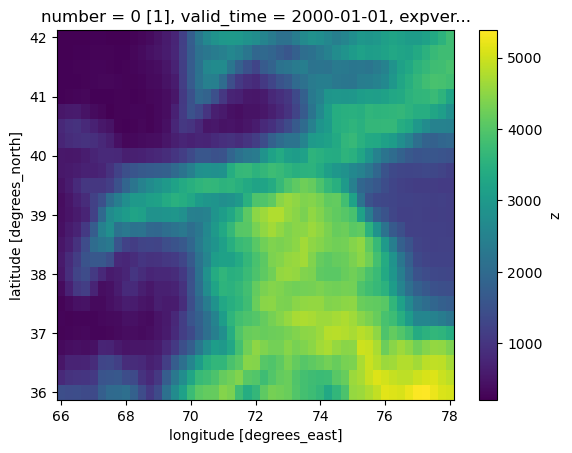

In [243]:
# ERA5 orography
orog_era5 = xr.open_mfdataset(folder_era5 + 'era5_GRf_t2m.nc').z.isel(valid_time=0).load()/9.80665
orog_era5=orog_era5.rename({'latitude':'lat', 'longitude':'lon'})
print(orog_era5.shape)
orog_era5[:,:].plot()

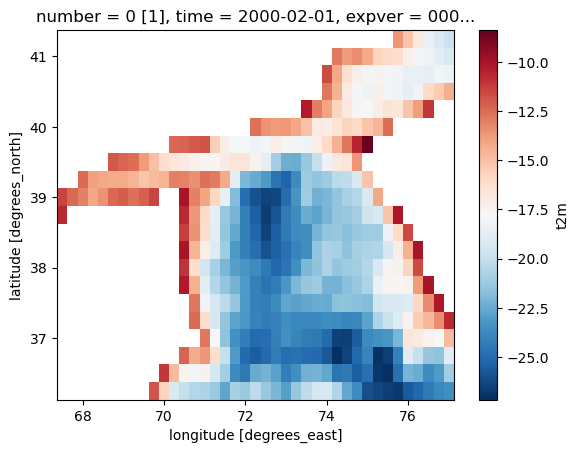

In [244]:
# Selection des données montagne vs plaine
orog_era5_on_tmp_grid = orog_era5.interp(
    lat=tmp_era5.lat,
    lon=tmp_era5.lon,
    method="linear"  
)

tmp_era5_high = tmp_era5.where(orog_era5_on_tmp_grid > alti_thrs)
tmp_era5_high.isel(time=1).plot(cmap='RdBu_r')

### ERA5-land

In [245]:
folder_era5land='/bettik/PROJECTS/pr-regional-climate/fainx/era5-land/'
tmp_era5land = xr.open_mfdataset(folder_era5land + 'era5_land_GRf_t2m.nc').t2m.load()-273.15

tmp_era5land=tmp_era5land.rename({'latitude':'lat', 'longitude':'lon'})
tmp_era5land = tmp_era5land.rename({'valid_time': 'time'})

tmp_era5land = tmp_era5land.sel(time=slice("2000-01-01", "2020-12-31"))
tmp_era5land = tmp_era5land.where((tmp_era5land.lat >= lat_min) & (tmp_era5land.lat <= lat_max), drop=True)
tmp_era5land = tmp_era5land.where((tmp_era5land.lon >= lon_min) & (tmp_era5land.lon <= lon_max), drop=True)

model3='ERA5-Land'
res3=str('0.1°x0.1°')

(61, 121)


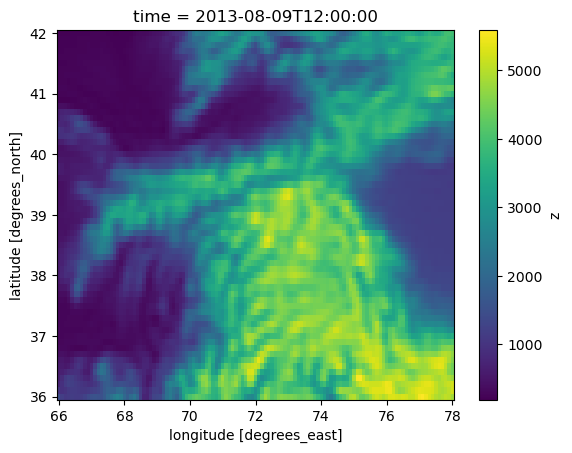

In [246]:
# ERA5-land orography
orog_era5land= xr.open_dataset(folder_era5land + 'geo.area-subset.42.78.36.66.nc').z.isel(time=0).load()/9.80665
orog_era5land=orog_era5land.rename({'latitude':'lat', 'longitude':'lon'})
print(orog_era5land.shape)
orog_era5land[:,:].plot()

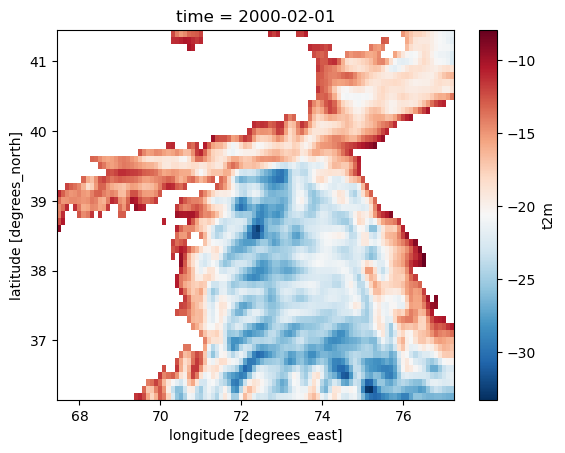

In [247]:
# Selection des données montagne vs plaine
orog_era5land_interp = orog_era5land.interp(
    lat=tmp_era5land.lat,
    lon=tmp_era5land.lon,
    method="linear"  
)

tmp_era5land_high = tmp_era5land.where(orog_era5land_interp > alti_thrs)
tmp_era5land_high
tmp_era5land_high.isel(time=1).plot(cmap='RdBu_r')

### CRU

In [248]:
# Could to download latest version of CRU data
# 2021-2023 data missing

folder_cru='/bettik/PROJECTS/pr-regional-climate/santolam/cru/'
tmp_cru = xr.open_mfdataset(folder_cru + 'cru_ts4.05.1901.2020.tmp.dat.nc').tmp.load()
tmp_cru = tmp_cru.where((tmp_cru.lat >= lat_min) & (tmp_cru.lat <= lat_max), drop=True)
tmp_cru = tmp_cru.where((tmp_cru.lon >= lon_min) & (tmp_cru.lon <= lon_max), drop=True)

tmp_cru=tmp_cru.sel(time=tmp_cru.time[np.isin(tmp_cru.time.dt.year,[2000, 2020])])

model4='CRU'
res4=str('0.5°x0.5°')

/nix/store/zc1wlsbnlcbacaiib6a5rgnf7fcjb9yc-python3-3.11.8-env/lib/python3.11/site-packages/xarray/coding/times.py:154: SerializationWarning: Ambiguous reference date string: 1-1-1 0:0:0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 0:0:0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  warnings.warn(warning_msg, SerializationWarning)
/nix/store/zc1wlsbnlcbacaiib6a5rgnf7fcjb9yc-python3-3.11.8-env/lib/python3.11/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/nix/store/zc1wlsbnlcbacaiib6a5rgnf7fcjb9yc-python3-3.11.8-env/lib/python3.11/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to d

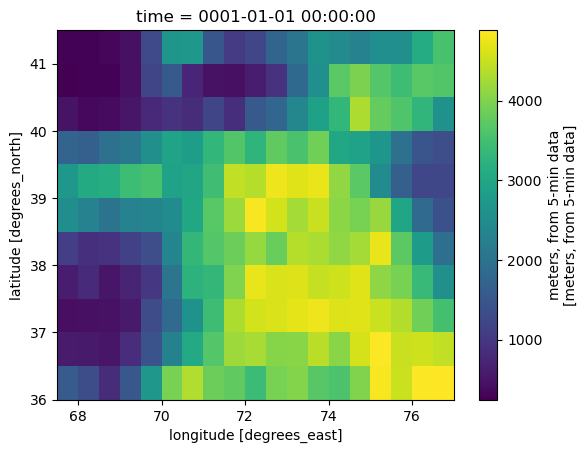

In [249]:
# JSIO orography for CRU
orog_jisao = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/fainx/jisao/' + 'jisao_elev.0.25-deg.nc').isel(time=0)

orog_cru=orog_jisao.interp(lat=tmp_cru.lat,lon=tmp_cru.lon)
orog_cru.data.plot()

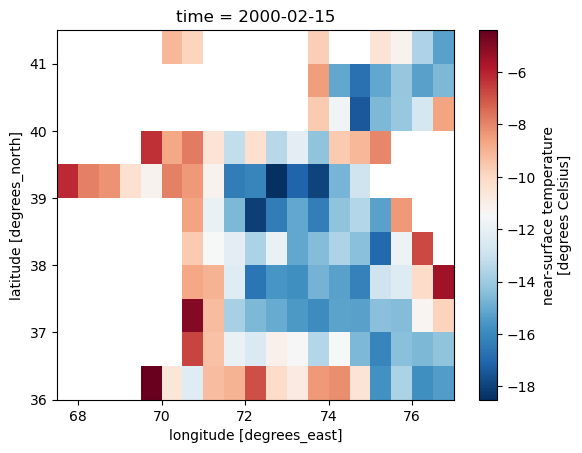

In [250]:
# Selection des données montagne vs plaine
orog_cru_interp = orog_cru.interp(
    lat=tmp_cru.lat,
    lon=tmp_cru.lon,
    method="linear"  
)

tmp_cru_high = tmp_cru.where(orog_cru_interp > alti_thrs)
tmp_cru_high = tmp_cru_high.data
tmp_cru_high.isel(time=1).plot(cmap='RdBu_r')

### HARv2

In [251]:
folder_HARv2='/bettik/PROJECTS/pr-regional-climate/santolam/HARv2/'
tmp_HARv2 = xr.open_mfdataset(folder_HARv2 + 'HARv2_mon_d10km_d_2d_t2_1980-2023.nc').t2.load()-273.15
tmp_HARv2= tmp_HARv2.sel(time=slice("2000-01-01", "2020-12-31"))

def xy_sel_dom(ds,domain):
    latS,latN,lonW,lonE,latlim,lonlim=dom.coord_domain(domain)
    lat_str = ''
    lon_str = ''
    other_dims_str = []
    for dim in ds.coords:
      #  print(dim)
        if dim in ['lat', 'latitude','LON']:
            lat_str = dim
        elif dim in ['lon', 'longitude','LAT']:
            lon_str = dim
        else:
            other_dims_str.append(dim)
    mask = (
        (latS < ds[lat_str]) & ( ds[lat_str] < latN) 
    & (lonW < ds[lon_str]) & ( ds[lon_str] < lonE)
    )
    field_dom=ds.where(mask,drop=True)
    return field_dom

tmp_HARv2=xy_sel_dom(tmp_HARv2,domain)
# tmp_HARv2=tmp_HARv2.sel(lat=latlim_grF,lon=lonlim_grF)

model5='HARv2'
res5=str('10kmx10km')

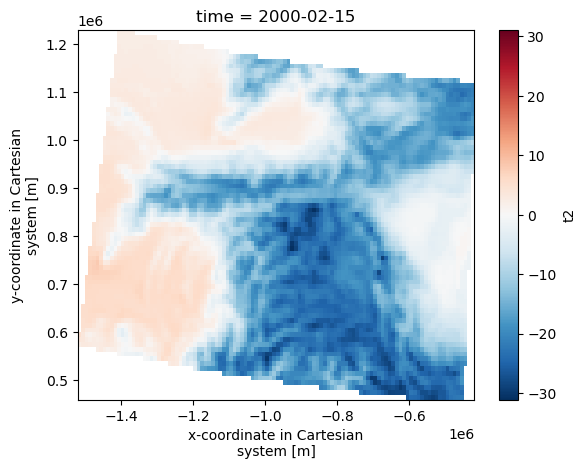

In [252]:
tmp_HARv2.isel(time=1).plot()

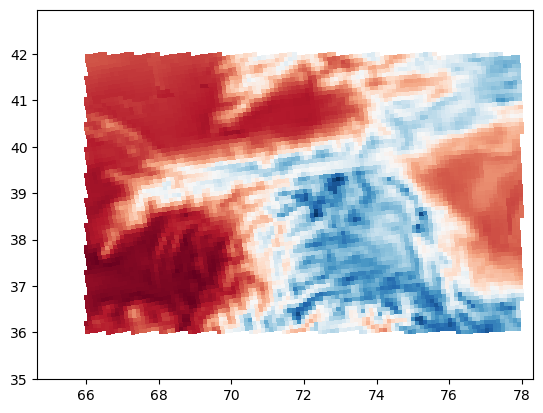

In [253]:
fig, ax = plt.subplots()
m = ax.pcolormesh(tmp_HARv2.lon, tmp_HARv2.lat, tmp_HARv2.isel(time=10),cmap='RdBu_r')     

In [254]:
# HARv2 Orography
orog_HARv2 = xr.open_mfdataset(folder_HARv2 + 'HARv2_d10km_static_hgt.nc').isel(time=0).hgt

orog_HARv2_interp = orog_HARv2.interp(
    west_east=tmp_HARv2.west_east,
    south_north=tmp_HARv2.south_north,
    method="linear"  
)
#orog_HARv2_interp.where(orog_HARv2_interp > alti_thrs).plot()

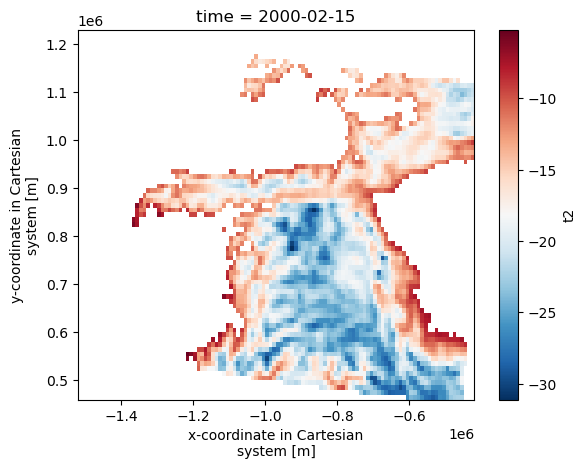

In [255]:
tmp_HARv2_high = tmp_HARv2.where(orog_HARv2_interp > alti_thrs)
tmp_HARv2_high.isel(time=1).plot(cmap='RdBu_r')

In [256]:
modelList=[model1,model2,model3,model4,model5]
resList=[res1,res2,res3,res4,res5]
print(modelList)
print(resList)

['MAR', 'ERA5', 'ERA5-Land', 'CRU', 'HARv2']
['5kmx5km', '31kmx31km', '0.1°x0.1°', '0.5°x0.5°', '10kmx10km']


## All altitudes included

In [257]:
dsList=[dsF,tmp_era5, tmp_era5land, tmp_cru, tmp_HARv2]

In [258]:
avgList=[]
for i,elem in enumerate(dsList):
    if i==0:
        print(i)
        print(modelList[i],resList[i])
        avg0=elem.mean(dim='X').mean(dim='Y')
    elif i in [1,2,3]:
        print(i)
        print(modelList[i],resList[i])
        avg0=elem.mean(dim='lon').mean(dim='lat')
    elif i in [4]:
        print(i)
        print(modelList[i],resList[i])
        avg0=elem.mean(dim='west_east').mean(dim='south_north')
    avgList.append(avg0)

0
MAR 5kmx5km
1
ERA5 31kmx31km
2
ERA5-Land 0.1°x0.1°
3
CRU 0.5°x0.5°
4
HARv2 10kmx10km


In [259]:
annualCycleList = []

for da in avgList:
    # Compute the climatological mean for each month
    clim = da.groupby('time.month').mean('time')
    annualCycleList.append(clim)

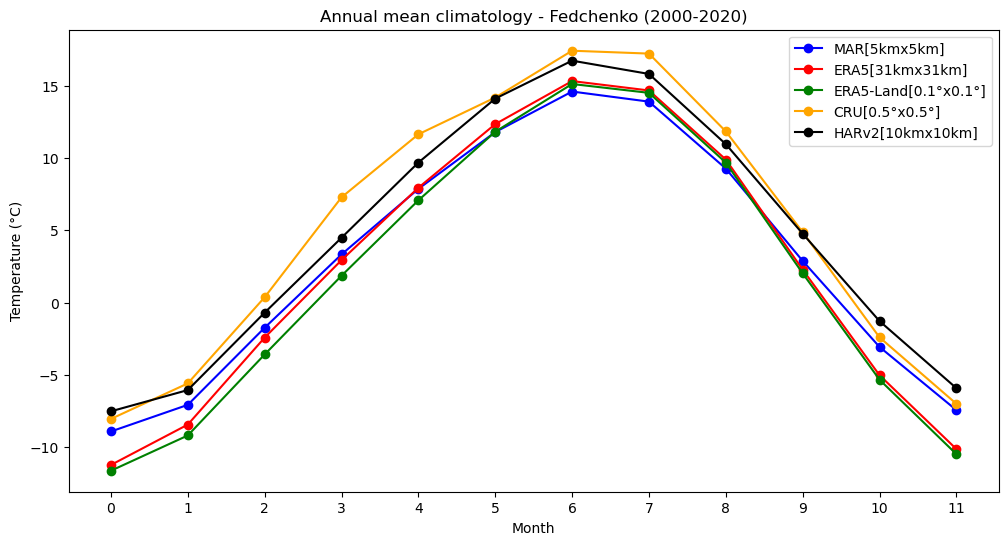

In [260]:
title="Annual mean climatology - Fedchenko (2000-2020)"

xmonths=np.arange(0,12,1)

fig, ax = plt.subplots(figsize=(12, 6))
my_ticks=xmonths

ax.plot(xmonths, annualCycleList[0], 'b',linestyle='-',marker='o',label=modelList[0]+'['+ resList[0]+']')

ax.plot(xmonths, annualCycleList[1], 'r',linestyle='-',marker='o',label=modelList[1]+'['+ resList[1]+']')
ax.plot(xmonths, annualCycleList[2], 'g',linestyle='-',marker='o',label=modelList[2]+'['+ resList[2]+']')
ax.plot(xmonths, annualCycleList[3], 'orange',linestyle='-',marker='o',label=modelList[3]+'['+ resList[3]+']')
ax.plot(xmonths, annualCycleList[4], 'black',linestyle='-',marker='o',label=modelList[4]+'['+ resList[4]+']')


ax.set_xlabel('Month')
ax.set_ylabel('Temperature (°C)')
ax.set_title(title)
freq=5
plt.xticks(xmonths,my_ticks,)
plt.legend()
plt.savefig(folder_figure+'AnnualClimato_'+ domain_2+ '_fulldomain.png',format='png')
plt.show()

## Only altitudes > alti_thrs included

In [261]:
dsList_high=[dsF_high,tmp_era5_high, tmp_era5land_high, tmp_cru_high, tmp_HARv2_high]

In [262]:
avgList=[]
for i,elem in enumerate(dsList_high):
    if i==0:
        print(i)
        print(modelList[i],resList[i])
        avg0=elem.mean(dim='X').mean(dim='Y')
    elif i in [1,2,3]:
        print(i)
        print(modelList[i],resList[i])
        avg0=elem.mean(dim='lon').mean(dim='lat')
    elif i in [4]:
        print(i)
        print(modelList[i],resList[i])
        avg0=elem.mean(dim='west_east').mean(dim='south_north')
    avgList.append(avg0)

0
MAR 5kmx5km
1
ERA5 31kmx31km
2
ERA5-Land 0.1°x0.1°
3
CRU 0.5°x0.5°
4
HARv2 10kmx10km


In [263]:
annualCycleList = []

for da in avgList:
    # Compute the climatological mean for each month
    clim = da.groupby('time.month').mean('time')
    annualCycleList.append(clim)

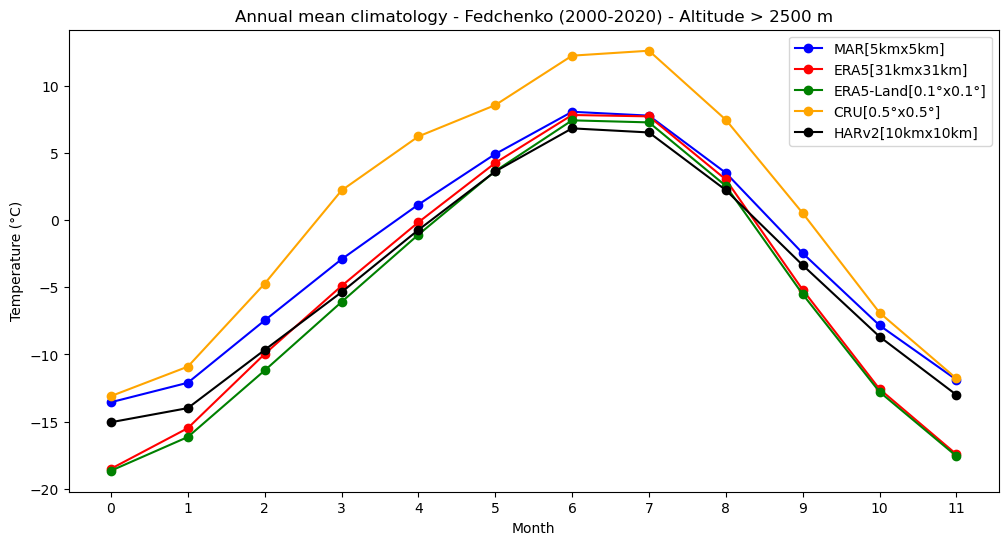

In [264]:
title='Annual mean climatology - Fedchenko (2000-2020) - Altitude > ' + str(alti_thrs) +' m'

xmonths=np.arange(0,12,1)

fig, ax = plt.subplots(figsize=(12, 6))
my_ticks=xmonths

ax.plot(xmonths, annualCycleList[0], 'b',linestyle='-',marker='o',label=modelList[0]+'['+ resList[0]+']')

ax.plot(xmonths, annualCycleList[1], 'r',linestyle='-',marker='o',label=modelList[1]+'['+ resList[1]+']')
ax.plot(xmonths, annualCycleList[2], 'g',linestyle='-',marker='o',label=modelList[2]+'['+ resList[2]+']')
ax.plot(xmonths, annualCycleList[3], 'orange',linestyle='-',marker='o',label=modelList[3]+'['+ resList[3]+']')
ax.plot(xmonths, annualCycleList[4], 'black',linestyle='-',marker='o',label=modelList[4]+'['+ resList[4]+']')


ax.set_xlabel('Month')
ax.set_ylabel('Temperature (°C)')
ax.set_title(title)
freq=5
plt.xticks(xmonths,my_ticks,)
plt.legend()
plt.savefig(folder_figure+'AnnualClimato_'+ domain_2+ '_'+ str(alti_thrs) +'m.png',format='png')
plt.show()